In [1]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns
import librosa
from pathlib import Path
import random
import shutil

Преобразование в удобный формат

In [ ]:
spkinfo = './datasets--evan0617--seniortalk/snapshots/d8f71863fff5d3128f806ca9025c653dd3dac397/'

In [3]:
file_path = os.path.join(spkinfo, 'SPKINFO.txt')

df = pd.read_csv(file_path, sep='\t', header=0)

In [4]:
df.head()

,SPEAKER_ID,GENDER,AGE,city DEVICE
0,1,M,81,北京 HUAWEI MGA-AL00
1,2,F,78,北京 HUAWEI MGA-AL00
2,3,F,77,浙江 HONOR AL10
3,4,F,76,浙江 HONOR AL10
4,5,F,76,北京 Iphone 13pro


In [ ]:
input_file = 'seniortalk_predictions.txt'
output_file = 'seniortalk_predictions.csv'

data = []
with open(input_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.rsplit(' ', 1)
            if len(parts) == 2:
                filename = parts[0]
                predicted_age = float(parts[1])
                data.append([filename, predicted_age])

df_preds = pd.DataFrame(data, columns=['filename', 'predicted_age'])

df_preds['speaker_id_file'] = df_preds['filename'].apply(
    lambda x: x.split('S')[0] if 'S' in x else x.split('.')[0]
)

df['SPEAKER_ID_str'] = df['SPEAKER_ID'].astype(str).str.zfill(3) 

age_dict = {}
for _, row in df.iterrows():
    spk_id = row['SPEAKER_ID_str']  # '001'
    age = row['AGE']
    
    for speaker in df_preds['speaker_id_file'].unique():
        if spk_id in speaker: 
            age_dict[speaker] = age
            break
        elif speaker.replace('Elderly', '').replace('Young', '').startswith(spk_id):
            age_dict[speaker] = age
            break

df_preds['true_age'] = df_preds['speaker_id_file'].map(age_dict)
df_preds = df_preds.rename(columns={'speaker_id_file': 'SPEAKER_ID'})
df_preds = df_preds[['filename', 'SPEAKER_ID', 'true_age', 'predicted_age']]
df_preds.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Файл сохранен: {output_file}")
print(f"\nКоличество записей: {len(df_preds)}")
print(f"Записей с true_age: {df_preds['true_age'].notna().sum()}")

Файл сохранен: seniortalk_predictions.csv

Количество записей: 5869
Записей с true_age: 4623


In [6]:
df_preds.head()

,filename,SPEAKER_ID,true_age,predicted_age
0,Elderly0014S0046W0001.wav,Elderly0014,77.0,51.61
1,Elderly0014S0046W0002.wav,Elderly0014,77.0,29.51
2,Elderly0014S0046W0003.wav,Elderly0014,77.0,50.76
3,Elderly0014S0046W0004.wav,Elderly0014,77.0,58.43
4,Elderly0014S0046W0005.wav,Elderly0014,77.0,46.56


In [7]:
len(df_preds)

5869

In [8]:
df_preds['error'] = df_preds['predicted_age'] - df_preds['true_age']  
df_preds['abs_error'] = abs(df_preds['error'])                  
df_preds['squared_error'] = df_preds['error'] ** 2              

# Метрики
MAE = abs(df_preds['predicted_age'] - df_preds['true_age']).mean()
MSE = ((df_preds['predicted_age'] - df_preds['true_age'])**2).mean()
RMSE = np.sqrt(MSE)
STD_ERROR = (df_preds['predicted_age'] - df_preds['true_age']).std()

# Дополнительные метрики в пределах
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100

print("Метрики оценки")

print(f"\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print(f"\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print(f"\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")

Метрики оценки

Основные метрики:
MAE  (Mean Absolute Error):     26.345 лет
RMSE (Root Mean Squared Error): 30.041 лет
Std of Error (разброс ошибок):  15.587 лет

Процент ошибок в пределах:
  ≤ 1 год:   1.1%
  ≤ 3 года:  3.5%
  ≤ 5 лет:   6.3%
  ≤ 10 лет:   12.6%

Статистика абсолютных ошибок:
  Мин ошибка:  0.020 лет
  Медиана:     26.510 лет
  Макс ошибка: 67.950 лет


In [9]:
df_preds['true_age'].dropna().unique()

array([77., 76., 75., 78., 79.])

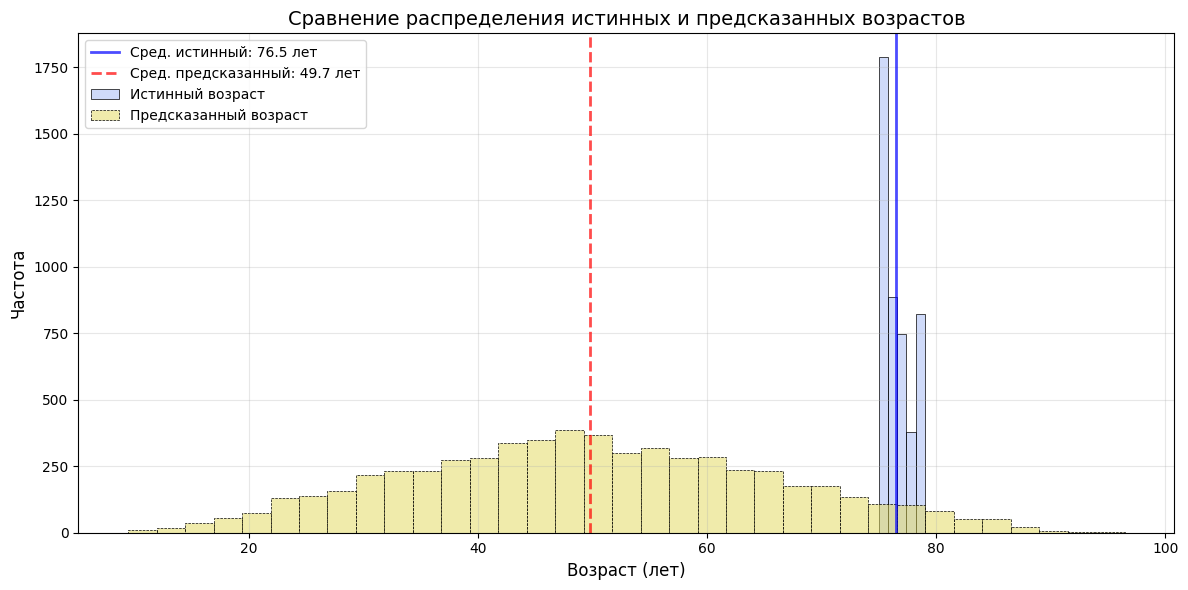

In [10]:
# Стилизованный вариант
plt.figure(figsize=(12, 6))

# Используем разные стили для наглядности
sns.histplot(data=df_preds, x='true_age', bins=5,
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='predicted_age',
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

# Добавляем вертикальные линии средних
plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['predicted_age'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["predicted_age"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()